# ClinVar Variant Pathogenicity Classifier

Predicting whether genomic variants are pathogenic or benign
using machine learning on 3.4 million ClinVar records.

**Key methodological decisions:**
- ReviewStatus used as sample weights, not a feature
- PhenotypeList excluded to avoid data leakage
- Only features available from sequencing used for prediction

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder

## 1. Load data

ClinVar variant_summary.txt contains 8.9M genomic variants
with clinical significance annotations from laboratories worldwide.

In [ ]:
df_full = pd.read_csv('../data/variant_summary.txt', sep='\t', low_memory=False)
print(f"Loaded: {df_full.shape[0]:,} rows, {df_full.shape[1]} columns")

## 2. Select columns and clean data

We select only columns relevant to our prediction task.
PhenotypeList is excluded — for a novel variant, no disease
associations exist yet, making this feature unavailable at
prediction time (data leakage).

In [ ]:
cols_needed = [
    'Type', 'GeneSymbol', 'ClinicalSignificance',
    'Chromosome', 'Start', 'ReviewStatus', 'Origin'
]
df_small = df_full[cols_needed].copy()
print(f"Selected {len(cols_needed)} columns")

Selected 7 columns


In [ ]:
label_map = {
    'Pathogenic': 'Pathogenic',
    'Likely pathogenic': 'Pathogenic',
    'Pathogenic/Likely pathogenic': 'Pathogenic',
    'Benign': 'Benign',
    'Likely benign': 'Benign',
    'Benign/Likely benign': 'Benign',
}
df_small['label'] = df_small['ClinicalSignificance'].map(label_map)
df_clean = df_small.dropna(subset=['label']).copy()

# Remove unknown chromosomes
bad = (
    df_clean['Chromosome'].isin(['na', 'Un']) |
    df_clean['Chromosome'].isna() |
    (df_clean['Chromosome'].astype(str) == 'nan')
)
df_clean = df_clean[~bad].copy()

print(f"After cleaning: {len(df_clean):,} rows")
print(df_clean['label'].value_counts())

After cleaning: 3,428,741 rows
label
Benign        2724344
Pathogenic     704397
Name: count, dtype: int64


## 3. Feature engineering

All features must be available from sequencing data alone —
no database metadata that would be absent for novel variants.

ReviewStatus is used as **sample weights** during training:
high-quality reviewed records contribute more to learning,
but the model predicts using only biological features.

In [ ]:
def clean_gene(gene):
    if gene == '-' or gene == '...':
        return 'unknown'
    if str(gene).startswith('subset of'):
        return 'unknown'
    if ';' in str(gene):
        return gene.split(';')[0]
    return gene

df_model = df_clean.copy()

# Gene
df_model['gene_clean'] = df_model['GeneSymbol'].apply(clean_gene)
le_gene = LabelEncoder()
df_model['gene_encoded'] = le_gene.fit_transform(df_model['gene_clean'])

# Chromosome
chrom_map = {str(i): i for i in range(1, 23)}
chrom_map.update({'X': 23, 'Y': 24, 'MT': 25})
df_model['chrom_num'] = df_model['Chromosome'].astype(str)\
    .map(chrom_map).fillna(0)

# Mutation type
le_type = LabelEncoder()
df_model['type_encoded'] = le_type.fit_transform(
    df_model['Type'].fillna('unknown'))

# Origin
origin_map = {'germline': 1, 'somatic': 2}
df_model['origin_encoded'] = df_model['Origin']\
    .str.split(';').str[0].map(origin_map).fillna(0)

# Sample weights from ReviewStatus
weight_map = {
    'practice guideline': 4.0,
    'reviewed by expert panel': 3.0,
    'criteria provided, multiple submitters, no conflicts': 2.0,
    'criteria provided, single submitter': 1.0,
    'no assertion criteria provided': 0.5,
    'no assertion provided': 0.5,
}
df_model['sample_weight'] = df_model['ReviewStatus']\
    .map(weight_map).fillna(0.5)

# Label
df_model['y'] = (df_model['label'] == 'Pathogenic').astype(int)

# Final X and y
features = ['chrom_num', 'Start', 'gene_encoded',
            'type_encoded', 'origin_encoded']

X = df_model[features].fillna(0)
y = df_model['y']
weights = df_model['sample_weight']

print(f"X shape: {X.shape}")
print(f"Pathogenic: {y.sum():,} | Benign: {(y==0).sum():,}")
X.head()

X shape: (3428741, 5)
Pathogenic: 704,397 | Benign: 2,724,344


,chrom_num,Start,gene_encoded,type_encoded,origin_encoded
0,7,4820844,787,3,1.0
1,7,4781213,787,3,1.0
2,7,4827361,787,1,1.0
3,7,4787730,787,1,1.0
6,11,126145284,5343,12,1.0


## 4. Train Random Forest

We use class_weight='balanced' to compensate for the 4:1
Benign:Pathogenic imbalance. ReviewStatus quality scores
are passed as sample_weight so reliable records influence
training more than unreviewed submissions.

In [ ]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

print("Training...")
clf.fit(X_train, y_train, sample_weight=w_train)
print("Done!")

Training...
Done!


## 5. Results

In [ ]:
# metrics
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred,
      target_names=['Benign', 'Pathogenic']))
print(f"ROC-AUC: {round(roc_auc_score(y_test, y_prob), 3)}")

              precision    recall  f1-score   support

      Benign       0.92      0.90      0.91    544869
  Pathogenic       0.63      0.69      0.66    140880

    accuracy                           0.85    685749
   macro avg       0.78      0.79      0.78    685749
weighted avg       0.86      0.85      0.86    685749

ROC-AUC: 0.865


chrom_num         0.031123
origin_encoded    0.054535
gene_encoded      0.099910
type_encoded      0.221620
Start             0.592811
dtype: float64


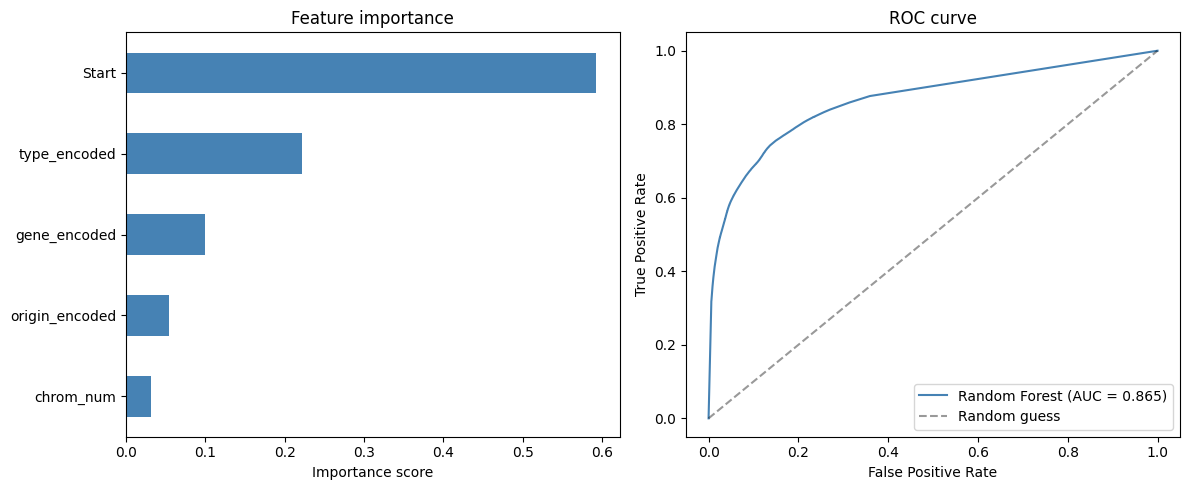

In [ ]:
# Cell 14 — figures
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Feature importance
importances = pd.Series(clf.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
print(importances.sort_values())
axes[0].set_title('Feature importance')
axes[0].set_xlabel('Importance score')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue',
             label=f'Random Forest (AUC = {round(roc_auc_score(y_test, y_prob), 3)})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4, label='Random guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/model_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Error analysis

We analyse where the model fails to identify systematic
limitations and guide future improvements.

In [ ]:
# gene error rates
test_df = df_model.loc[X_test.index].copy()
test_df['predicted'] = clf.predict(X_test)
test_df['correct'] = (test_df['predicted'] == test_df['y'])

gene_stats = test_df.groupby('gene_clean').agg(
    total            = ('y', 'count'),
    total_pathogenic = ('y', 'sum'),
    fn = ('y', lambda x: (
        (test_df.loc[x.index, 'y']==1) & 
        (test_df.loc[x.index, 'predicted']==0)
    ).sum()),
    fp = ('y', lambda x: (
        (test_df.loc[x.index, 'y']==0) & 
        (test_df.loc[x.index, 'predicted']==1)
    ).sum()),
)

gene_stats = gene_stats[
    (gene_stats['total'] >= 100) & 
    (gene_stats['total_pathogenic'] >= 30)
]

gene_stats['fn_rate'] = (gene_stats['fn'] / 
    gene_stats['total_pathogenic'].clip(lower=1)).round(3)
gene_stats['fp_rate'] = (gene_stats['fp'] / 
    (gene_stats['total'] - gene_stats['total_pathogenic']).clip(lower=1)).round(3)

print("Highest false negative rate:")
print(gene_stats['fn_rate'].sort_values(ascending=False).head(10))
print("\nHighest false positive rate:")
print(gene_stats['fp_rate'].sort_values(ascending=False).head(10))

Highest false negative rate:
gene_clean
RELN        0.810
C2CD3       0.806
DOCK7       0.805
LRP2        0.800
PNPT1       0.800
ANK2        0.788
RTTN        0.778
ADAMTS18    0.767
HSPG2       0.766
ELAC2       0.765
Name: fn_rate, dtype: float64

Highest false positive rate:
gene_clean
GBA1    0.771
GJB1    0.646
TYR     0.625
F8      0.610
GCK     0.580
MPZ     0.571
F9      0.560
PAH     0.550
IDS     0.547
GLA     0.544
Name: fp_rate, dtype: float64


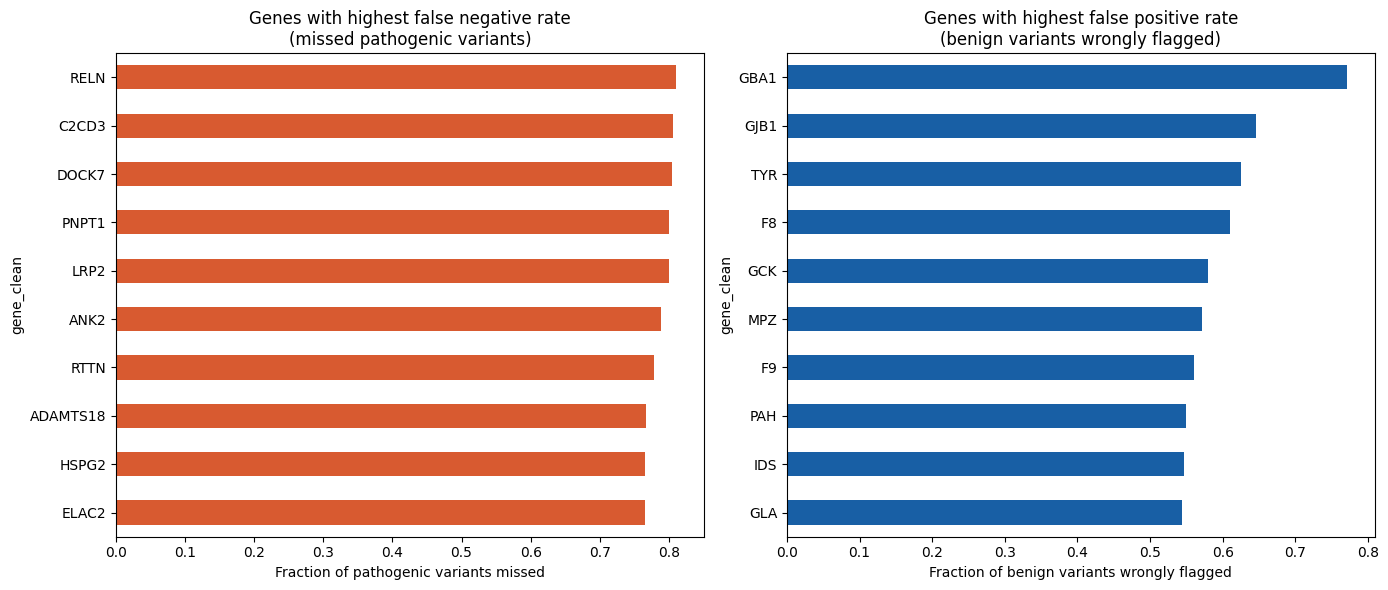

In [ ]:
#error analysis figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_fn = gene_stats['fn_rate'].sort_values(ascending=False).head(10)
top_fn.sort_values().plot(kind='barh', ax=axes[0], color='#D85A30')
axes[0].set_title('Genes with highest false negative rate\n(missed pathogenic variants)')
axes[0].set_xlabel('Fraction of pathogenic variants missed')

top_fp = gene_stats['fp_rate'].sort_values(ascending=False).head(10)
top_fp.sort_values().plot(kind='barh', ax=axes[1], color='#185FA5')
axes[1].set_title('Genes with highest false positive rate\n(benign variants wrongly flagged)')
axes[1].set_xlabel('Fraction of benign variants wrongly flagged')

plt.tight_layout()
plt.savefig('../results/figures/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Error rate by mutation type
type_stats = test_df.groupby('Type').agg(
    total            = ('y', 'count'),
    total_pathogenic = ('y', 'sum'),
    errors           = ('correct', lambda x: (~x).sum()),
    fn               = ('y', lambda x: (
                        (test_df.loc[x.index, 'y']==1) & 
                        (test_df.loc[x.index, 'predicted']==0)
                       ).sum()),
    fp               = ('y', lambda x: (
                        (test_df.loc[x.index, 'y']==0) & 
                        (test_df.loc[x.index, 'predicted']==1)
                       ).sum()),
)
type_stats['error_rate'] = (type_stats['errors'] / 
                             type_stats['total']).round(3)
type_stats['fn_rate'] = (type_stats['fn'] / 
                          type_stats['total_pathogenic'].clip(lower=1)).round(3)
type_stats['fp_rate'] = (type_stats['fp'] / 
                         (type_stats['total'] - type_stats['total_pathogenic']
                         ).clip(lower=1)).round(3)

print("Error rate by mutation type")
print(type_stats[['total', 'error_rate', 'fn_rate', 'fp_rate']]\
    .sort_values('error_rate', ascending=False))

=== Error rate by mutation type ===
                            total  error_rate  fn_rate  fp_rate
Type                                                           
Microsatellite              10218       0.218    0.264    0.182
Duplication                 21945       0.205    0.137    0.341
Insertion                    4374       0.179    0.175    0.184
Deletion                    51766       0.169    0.101    0.379
Indel                        3533       0.163    0.085    0.491
single nucleotide variant  587105       0.140    0.484    0.091
copy number loss             3680       0.108    0.071    0.190
Inversion                     204       0.103    0.197    0.063
copy number gain             2744       0.084    0.122    0.059
Variation                     161       0.012    0.500    0.006
Complex                        10       0.000    0.000    0.000
Translocation                   9       0.000    0.000    0.000


In [ ]:
# Error rate by chromosome
chrom_stats = test_df.groupby('Chromosome').agg(
    total            = ('y', 'count'),
    total_pathogenic = ('y', 'sum'),
    errors           = ('correct', lambda x: (~x).sum()),
    fn               = ('y', lambda x: (
                        (test_df.loc[x.index, 'y']==1) & 
                        (test_df.loc[x.index, 'predicted']==0)
                       ).sum()),
    fp               = ('y', lambda x: (
                        (test_df.loc[x.index, 'y']==0) & 
                        (test_df.loc[x.index, 'predicted']==1)
                       ).sum()),
)
chrom_stats['error_rate'] = (chrom_stats['errors'] / 
                              chrom_stats['total']).round(3)
chrom_stats['fn_rate'] = (chrom_stats['fn'] / 
                           chrom_stats['total_pathogenic'].clip(lower=1)).round(3)
chrom_stats['fp_rate'] = (chrom_stats['fp'] / 
                          (chrom_stats['total'] - chrom_stats['total_pathogenic']
                          ).clip(lower=1)).round(3)
chrom_stats['pathogenic_rate'] = (chrom_stats['total_pathogenic'] / 
                                   chrom_stats['total']).round(3)

print("Error rate by chromosome")
print(chrom_stats[['total', 'pathogenic_rate', 'error_rate', 'fn_rate', 'fp_rate']]\
    .sort_values('error_rate', ascending=False))

=== Error rate by chromosome ===
            total  pathogenic_rate  error_rate  fn_rate  fp_rate
Chromosome                                                      
X           31596            0.335       0.185    0.226    0.164
2           66977            0.222       0.167    0.310    0.126
13          14860            0.320       0.164    0.212    0.141
15          24733            0.227       0.161    0.302    0.120
11          39048            0.219       0.160    0.322    0.114
6           30164            0.208       0.160    0.351    0.110
8           22749            0.194       0.151    0.358    0.101
5           33161            0.199       0.150    0.327    0.106
17          42431            0.268       0.148    0.240    0.114
1           58690            0.176       0.147    0.347    0.104
3           36428            0.196       0.146    0.336    0.100
12          29803            0.195       0.141    0.334    0.095
10          24779            0.168       0.140    0.367  

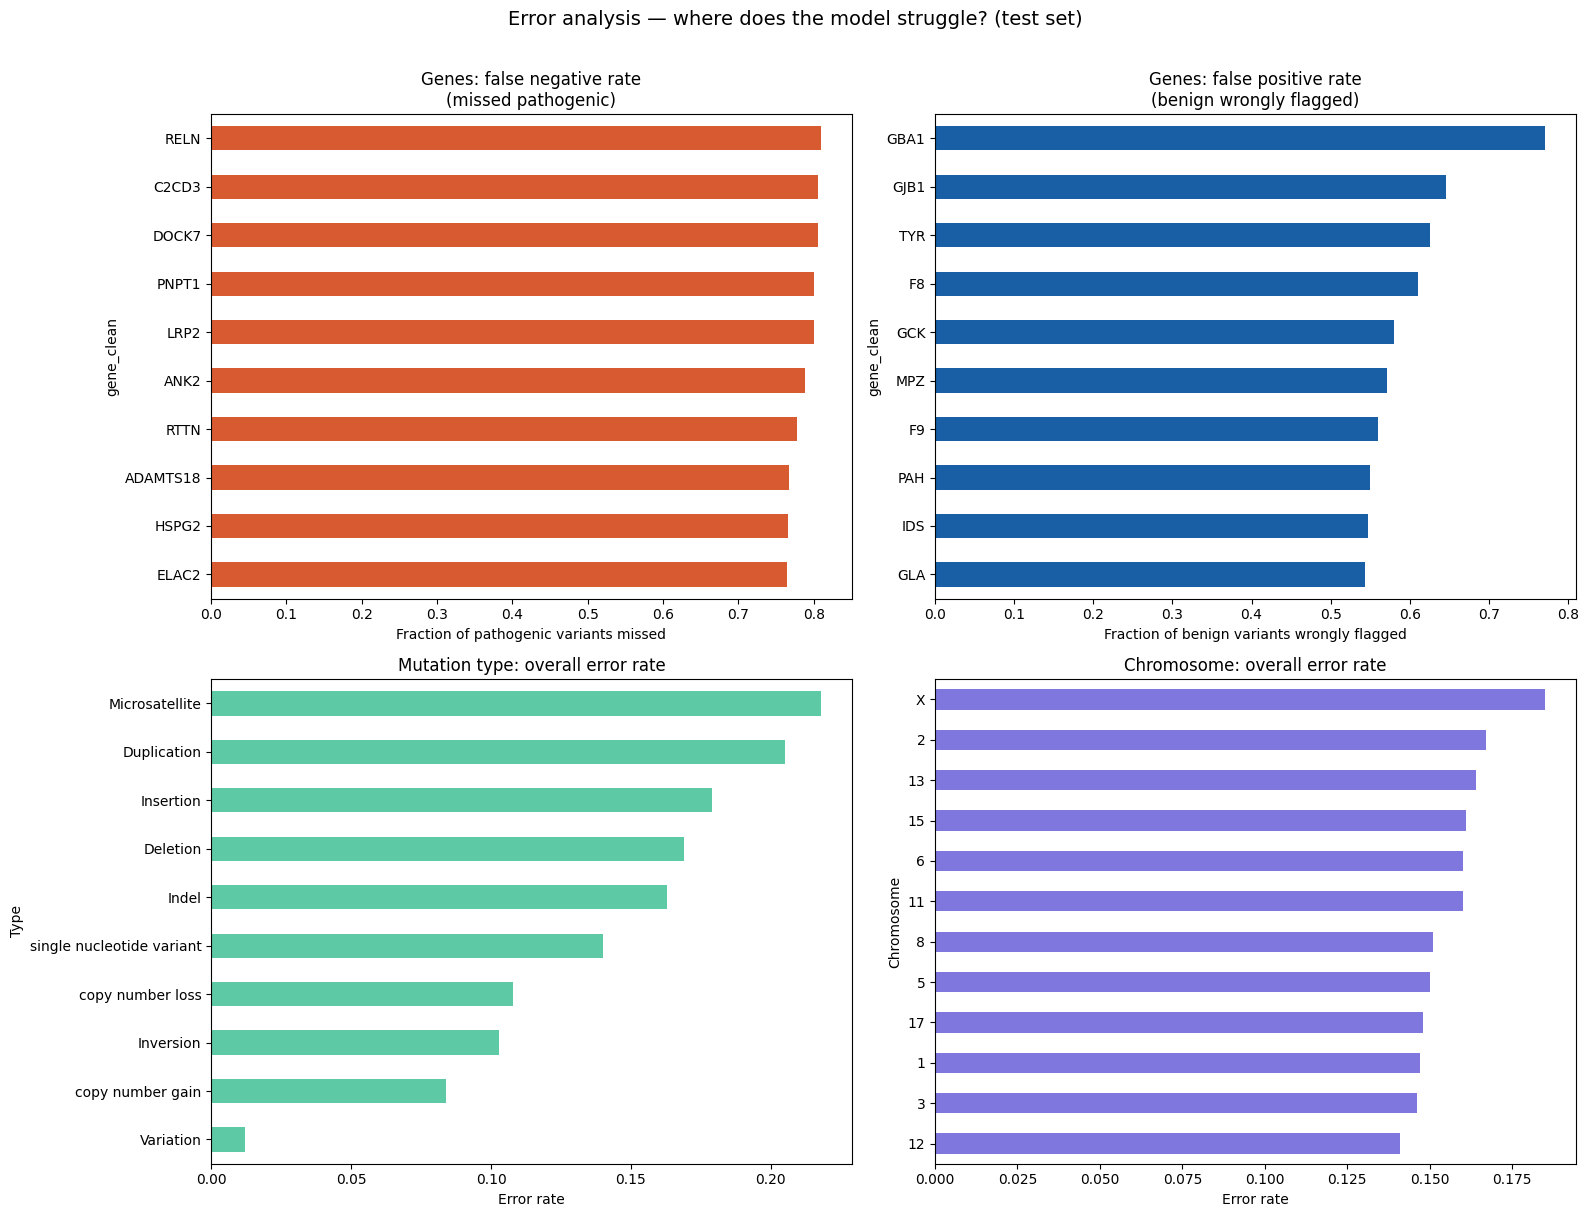

Saved!


In [ ]:
# Visualization of error analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#gene false negative rate
top_fn = gene_stats['fn_rate'].sort_values(ascending=False).head(10)
top_fn.sort_values().plot(kind='barh', ax=axes[0,0], color='#D85A30')
axes[0,0].set_title('Genes: false negative rate\n(missed pathogenic)')
axes[0,0].set_xlabel('Fraction of pathogenic variants missed')

#gene false positive rate
top_fp = gene_stats['fp_rate'].sort_values(ascending=False).head(10)
top_fp.sort_values().plot(kind='barh', ax=axes[0,1], color='#185FA5')
axes[0,1].set_title('Genes: false positive rate\n(benign wrongly flagged)')
axes[0,1].set_xlabel('Fraction of benign variants wrongly flagged')

#mutation type
type_plot = type_stats[type_stats['total'] >= 100]['error_rate']\
    .sort_values(ascending=False)
type_plot.sort_values().plot(kind='barh', ax=axes[1,0], color='#5DCAA5')
axes[1,0].set_title('Mutation type: overall error rate')
axes[1,0].set_xlabel('Error rate')

#chromosome
chrom_plot = chrom_stats['error_rate'].sort_values(ascending=False).head(12)
chrom_plot.sort_values().plot(kind='barh', ax=axes[1,1], color='#7F77DD')
axes[1,1].set_title('Chromosome: overall error rate')
axes[1,1].set_xlabel('Error rate')

plt.suptitle('Error analysis — where does the model struggle? (test set)', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/error_analysis.png', 
            dpi=150, bbox_inches='tight')
plt.show()


## 7. Conclusions and limitations

**What works well:**
- ROC-AUC of 0.865 using only 5 sequencing-derived features
- Genomic position (Start) is the most informative feature (59%)
- Overall error rate of 14.6% on unseen test data

**Where the model struggles:**
- SNVs have the highest false negative rate (48%) despite being most common
- Genes like RELN (81%) and GBA1 (77%) show very high error rates
- Chromosome X has the highest error rate (18.5%)
- Microsatellites and duplications are hardest to classify overall

**Why — biological interpretation:**
Genomic position alone is insufficient for pathogenicity prediction.
Two distinct error patterns emerge: genes like RELN and DOCK7 where
pathogenicity depends on protein domain context, and genes like GBA1
and GJB1 where benign variants cluster near pathogenic hotspots.
Both point to the same gap — the model lacks protein structure
and population frequency information.

**Future work:**
- Protein domain annotation (UniProt) to address domain-dependent genes
- Evolutionary conservation scores (PhyloP) to improve SNV classification
- Population frequency (gnomAD) to address false positives in GBA1, GJB1
- Separate models for germline vs somatic variants
- X-chromosome specific features for hemizygous inheritance patterns